KB 09October2025

Try to use Psytrack 

Link: https://github.com/nicholas-roy/psytrack/blob/master/psytrack/examples/ExampleNotebook.ipynb

Link2: https://github.com/davcrom/ibl_neuromodulators/blob/main/behaviour/PsyTrack_defpip.ipynb


In [4]:
""" 1. IMPORTS """ 
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
from functions import *
import sys
sys.path.insert(0, "/home/kceniabougrova/Documents/GitHub/ibl-photometry/src")


df_good_BCW = pd.read_excel("/home/kceniabougrova/Downloads/good_sessions_outputs/df_good_BCW.xlsx")

i = 4
row = df_good_BCW.iloc[i]

# =========================================================
# Extract metadata
# =========================================================
subject = row['subject']
date = str(row['date'])[:10]
region = row['region']
fiber = row['fiber']
eid = row['eid']

print(f"📦 Session {i} — {subject} | {date} | {region} | {fiber} | {eid}")

# =========================================================
# Locate corresponding files in your folder
# =========================================================
BASE_DIR = "/home/kceniabougrova/Downloads/good_sessions_outputs/"

df_trials_file = [
    f for f in os.listdir(BASE_DIR)
    if f.startswith("df_trials_")
    and subject in f
    and date in f
    and region in f
    and eid in f
]

df_nph_file = [
    f for f in os.listdir(BASE_DIR)
    if f.startswith("df_nph_")
    and subject in f
    and date in f
    and region in f
    and eid in f
]

if not df_trials_file or not df_nph_file:
    print("⚠️ Missing one or both files in folder!")
else:
    df_trials_path = os.path.join(BASE_DIR, df_trials_file[0])
    df_nph_path = os.path.join(BASE_DIR, df_nph_file[0])

    print(f"✅ Found df_trials -> {df_trials_path}")
    print(f"✅ Found df_nph -> {df_nph_path}")

    # Load them
    df_trials = pd.read_csv(df_trials_path)
    df_nph = pd.read_csv(df_nph_path)

    print(f"df_trials shape: {df_trials.shape}")
    print(f"df_nph shape: {df_nph.shape}")

📦 Session 4 — ZFM-03059 | 2021-10-11 | Region1G | probe01 | 8e90ac76-47c7-441b-b370-204a8002abd8
✅ Found df_trials -> /home/kceniabougrova/Downloads/good_sessions_outputs/df_trials_7_ZFM-03059_2021-10-11_Region1G_8e90ac76-47c7-441b-b370-204a8002abd8.csv
✅ Found df_nph -> /home/kceniabougrova/Downloads/good_sessions_outputs/df_nph_7_ZFM-03059_2021-10-11_Region1G_8e90ac76-47c7-441b-b370-204a8002abd8.csv
df_trials shape: (633, 29)
df_nph shape: (48893, 4)


In [44]:
D = df_trials.copy()
D['y'] = D['choice'].replace({-1: 1, 1: 2})   # map -1 → 1, 1 → 2
D = D[D['choice'] != 0]                       # remove trials where choice == 0

print("The keys of the dict for this example animal:\n   ", list(D.keys()))
print("The shape of y:   ", D['y'].shape)
print("The number of trials:   N =", D['y'].shape[0])
print("The unique entries of y:   ", np.unique(D['y']))



The keys of the dict for this example animal:
    ['stimOffTrigger_times', 'stimOff_times', 'allContrasts', 'allSContrasts', 'goCueTrigger_times', 'included', 'quiescencePeriod', 'stimOnTrigger_times', 'goCue_times', 'response_times', 'choice', 'stimOn_times', 'contrastLeft', 'contrastRight', 'feedback_times', 'feedbackType', 'rewardVolume', 'probabilityLeft', 'firstMovement_times', 'intervals_0', 'intervals_1', 'subject', 'date', 'eid', 'reactionTime', 'responseTime', 'quiescenceTime', 'trialTime', 'trialNumber', 'y']
The shape of y:    (676,)
The number of trials:   N = 676
The unique entries of y:    [1. 2.]


In [5]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.dpi'] = 140

import psytrack as psy

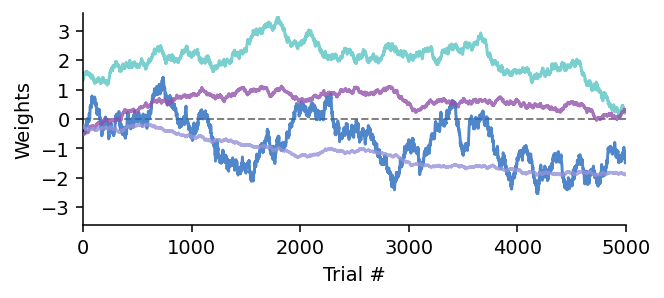

In [6]:
seed = 31
num_weights = 4
num_trials = 5000
hyper = {'sigma'   : 2**np.array([-4.0,-5.0,-6.0,-7.0]),
         'sigInit' : 2**np.array([ 0.0, 0.0, 0.0, 0.0])}

# Simulate
simData = psy.generateSim(K=num_weights, N=num_trials, hyper=hyper,
                          boundary=6.0, iterations=1, seed=seed, savePath=None)

# Plot
psy.plot_weights(simData['W'].T);
plt.ylim(-3.6,3.6);

In [20]:
hyper[0].shape

KeyError: 0

In [7]:
rec = psy.recoverSim(simData)

In [8]:
rec

{'iteration': 0,
 'N': 5000,
 'K': 4,
 'input': {'sigInit': array([1., 1., 1., 1.]),
  'sigDay': None,
  'sigma': array([0.0625   , 0.03125  , 0.015625 , 0.0078125]),
  'dayLength': None,
  'seed': 31,
  'W': array([[-0.4343693 ,  1.34700479, -0.49779972, -0.2405024 ],
         [-0.43356056,  1.32084552, -0.49964051, -0.25749655],
         [-0.47947976,  1.34969436, -0.51976486, -0.25537572],
         ...,
         [-1.48016105,  0.33025206,  0.27561389, -1.8873101 ],
         [-1.42635657,  0.29754755,  0.28747175, -1.90199806],
         [-1.49545299,  0.2715588 ,  0.27901971, -1.90278552]]),
  'X': array([[-1.53838712,  0.42103903,  0.41645744, -0.68211591],
         [ 0.10428459, -1.51795415, -0.57449161, -0.05326662],
         [ 0.64070616,  2.27887192,  0.72229007, -0.66272997],
         ...,
         [ 0.26584933,  2.0332635 , -0.7496208 ,  0.47398381],
         [-0.17065255,  0.06548138,  0.50212868,  1.55632706],
         [ 1.20698087, -0.53682278, -0.60912088, -0.17290518]]),


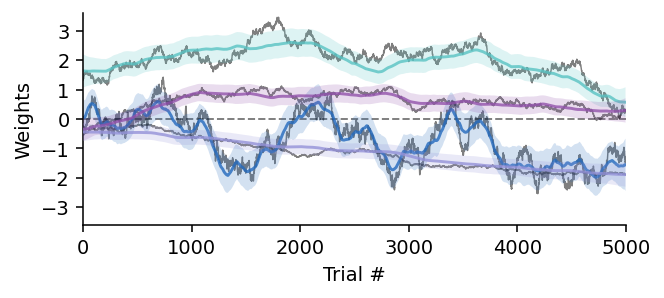

In [9]:
psy.plot_weights(rec['wMode'], errorbar=rec["hess_info"]["W_std"])
plt.plot(simData['W'], c="k", ls="-", alpha=0.5, lw=0.75, zorder=0)
plt.ylim(-3.6,3.6);


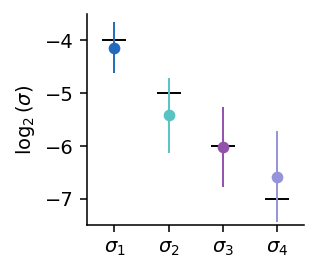

In [10]:
true_sigma = np.log2(rec['input']['sigma'])
avg_sigma = np.log2(rec['hyp']['sigma'])
err_sigma = rec['hess_info']['hyp_std']

plt.figure(figsize=(2,2))
colors = np.unique(list(psy.COLORS.values()))
for i in range(num_weights):
    plt.plot(i, true_sigma[i], color="black", marker="_", markersize=12, zorder=0)
    plt.errorbar([i], avg_sigma[i], yerr=2*err_sigma[i], color=colors[i], lw=1, marker='o', markersize=5)

plt.xticks([0,1,2,3]); plt.yticks(np.arange(-8,-2))
plt.gca().set_xticklabels([r"$\sigma_1$", r"$\sigma_2$", r"$\sigma_3$", r"$\sigma_4$"])
plt.xlim(-0.5,3.5); plt.ylim(-7.5,-3.5)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.ylabel(r"$\log_2(\sigma)$");

In [33]:
D = df_trials.copy()
D['y'] = D['choice'].replace({-1: 1, 1: 2})   # map -1 → 1, 1 → 2
D['feedbackType'] = D['feedbackType'].replace({-1: 1, 1: 2})   # map -1 → 1, 1 → 2
D = D[D['choice'] != 0] 
D

,quiescencePeriod,included,allContrasts,allSContrasts,stimOff_times,goCueTrigger_times,stimOffTrigger_times,stimOnTrigger_times,goCue_times,response_times,...,intervals_1,subject,date,eid,reactionTime,responseTime,quiescenceTime,trialTime,trialNumber,y
0,0.609936,True,1.000,-1.000,5.705700,3.977200,5.648200,3.877100,3.994400,4.648100,...,6.205702,ZFM-03059,2021-10-11,8e90ac76-47c7-441b-b370-204a8002abd8,0.304542,0.7710,3.8771,6.205702,1,2.0
1,0.408291,True,0.000,0.000,58.922500,7.457100,58.860100,7.397800,7.483800,57.860000,...,59.422502,ZFM-03059,2021-10-11,8e90ac76-47c7-441b-b370-204a8002abd8,0.881842,50.4622,0.4084,52.433102,2,1.0
2,0.632563,True,0.000,0.000,85.571400,61.971200,85.516900,61.917800,62.003900,84.516800,...,86.071402,ZFM-03059,2021-10-11,8e90ac76-47c7-441b-b370-204a8002abd8,7.061842,22.5990,1.7483,25.901902,3,1.0
4,0.532917,True,0.250,-0.250,153.804700,152.454600,153.743800,152.395100,152.486500,152.743700,...,154.304702,ZFM-03059,2021-10-11,8e90ac76-47c7-441b-b370-204a8002abd8,0.254542,0.3486,0.7386,2.648202,5,2.0
5,0.563320,True,0.250,-0.250,158.686199,157.236499,158.623899,157.190799,157.264099,157.623799,...,159.186202,ZFM-03059,2021-10-11,8e90ac76-47c7-441b-b370-204a8002abd8,0.245843,0.4330,2.1944,4.189803,6,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
626,0.554065,True,0.125,0.125,3053.802299,3049.502599,3053.742499,3049.444999,3049.535999,3051.742399,...,3054.302301,ZFM-03059,2021-10-11,8e90ac76-47c7-441b-b370-204a8002abd8,1.912643,2.2974,1.8329,6.690202,627,2.0
627,0.500032,True,1.000,1.000,3057.251199,3055.584899,3057.198999,3055.540799,3055.614799,3056.198899,...,3057.751201,ZFM-03059,2021-10-11,8e90ac76-47c7-441b-b370-204a8002abd8,0.261843,0.6581,0.5002,2.710602,628,1.0
628,0.656389,True,1.000,-1.000,3061.452098,3060.118598,3061.387798,3060.056198,3060.148398,3060.387698,...,3061.952101,ZFM-03059,2021-10-11,8e90ac76-47c7-441b-b370-204a8002abd8,0.201444,0.3315,1.5842,3.480103,629,2.0
630,0.662723,True,1.000,-1.000,3129.084099,3127.433399,3129.014599,3127.374099,3127.463999,3128.014499,...,3129.584101,ZFM-03059,2021-10-11,8e90ac76-47c7-441b-b370-204a8002abd8,0.507543,0.6404,0.6629,2.872902,631,2.0


2nd link

In [34]:
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.dpi'] = 140

import psytrack as psy
import pandas as pd
import seaborn as sns

In [35]:
df = df_trials.copy()
df_m = df.copy()

In [36]:
df_m[['choice', 'contrastLeft']] # print only the data in which you're interested to

df_m[['contrastLeft']] = df_m[['contrastLeft']].fillna(0)


In [37]:
input={
    'y': np.array([2 if c < 0 else 1 for c in df_m['choice']]), 
    'inputs': {
        # 's1': np.abs(df_m['contrastRight']).values.reshape(-1, 1),
        's2': np.abs(df_m['contrastLeft']).values.reshape(-1, 1)
            }
    }

In [38]:
weights = {'bias': 1,  # a special key
           's1': 1,
           's2': 1
           } 

# It is often useful to have the total number of weights K in your model
K = np.sum([weights[i] for i in weights.keys()])


In [39]:
hyper= {'sigInit': 2**4.,      # Set to a single, large value for all weights. Will not be optimized further.
       'sigma': [2**-6]*K
       }

In [40]:
optList = ['sigma']

In [41]:


# Psytrack function 
hyp, evd, wMode, hess_info = psy.hyperOpt(input, hyper, weights, optList)



Exception: s1 given in weights not in dataset inputs

In [42]:
wMode

array([[  0.38673379,   0.3867462 ,   0.38343549, ...,  -1.73386864,
         -1.74328535,  -1.74450731],
       [ 30.91949079,  30.91952691,  30.91956303, ...,  30.91227966,
         30.91220508,  30.91220508],
       [-34.68873451, -34.68878346, -34.68883241, ..., -34.68645582,
        -34.68645582, -34.68645582]])

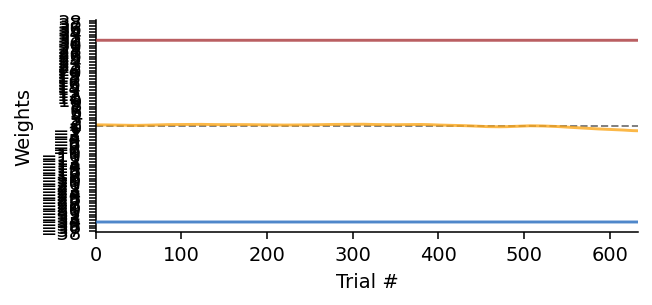

In [43]:


# Psytrack plot
fig = psy.plot_weights(wMode, weights)



NEW TRIAL, NO PSYTRACK, ONLY GLM 

✅ N trials: 632
Unique feedbackType (mapped to correct): [1 0]
   allSContrasts  choice  probabilityLeft  prev_choice  prev_feedback
0           0.00    -1.0              0.5          1.0            1.0
1           0.00    -1.0              0.5         -1.0            1.0
2           0.00     0.0              0.5         -1.0            1.0
3          -0.25     1.0              0.5          0.0           -1.0
4          -0.25     1.0              0.5          1.0            1.0
Optimization terminated successfully.
         Current function value: 0.306619
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                correct   No. Observations:                  632
Model:                          Logit   Df Residuals:                      626
Method:                           MLE   Df Model:                            5
Date:                Thu, 09 Oct 2025   Pseudo R-squ.:                 0.02292
Time:               

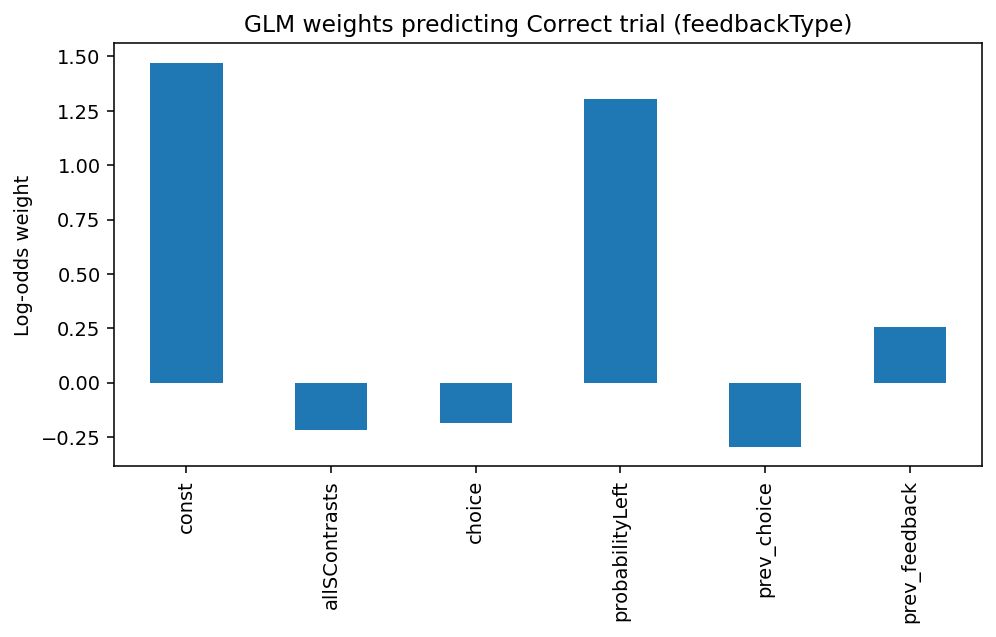

In [72]:
"""
KB 09102025
Code to use GLM on 1 session to predict from 3 variables the outcome variable feedbackType (1 = correct, 0 = incorrect) 
"""
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# =========================================================
# 1. Prepare data
# =========================================================
D = df_trials.copy().reset_index(drop=True)

# Outcome variable: 1 = correct, 0 = incorrect
D['correct'] = D['feedbackType'].replace({-1: 0, 1: 1}).astype(int)

# Predictors
D['choice_right'] = D['choice'].replace({-1: 0, 0: 0, 1: 1}).astype(int)
D['prev_choice']   = D['choice'].shift(1)
D['prev_feedback'] = D['feedbackType'].shift(1)
# Predictors
predictors = ['allSContrasts', 'choice', 'probabilityLeft', 'prev_choice', 'prev_feedback']

# Ensures that all the predictor columns are numeric
for c in predictors:
    D[c] = pd.to_numeric(D[c], errors='coerce')

# Drop NaNs
D = D.dropna(subset=predictors + ['correct']).reset_index(drop=True)

print("✅ N trials:", len(D))
print("Unique feedbackType (mapped to correct):", D['correct'].unique())
print(D[predictors].head())

# =========================================================
# 2. Fit logistic regression
# =========================================================
X = sm.add_constant(D[predictors])
y = D['correct']

model = sm.Logit(y, X)
result = model.fit()
print(result.summary())

# =========================================================
# 3. Visualize coefficients
# =========================================================
plt.figure(figsize=(8,4))
result.params.plot(kind='bar')
plt.ylabel('Log-odds weight')
plt.title('GLM weights predicting Correct trial (feedbackType)')
plt.show()


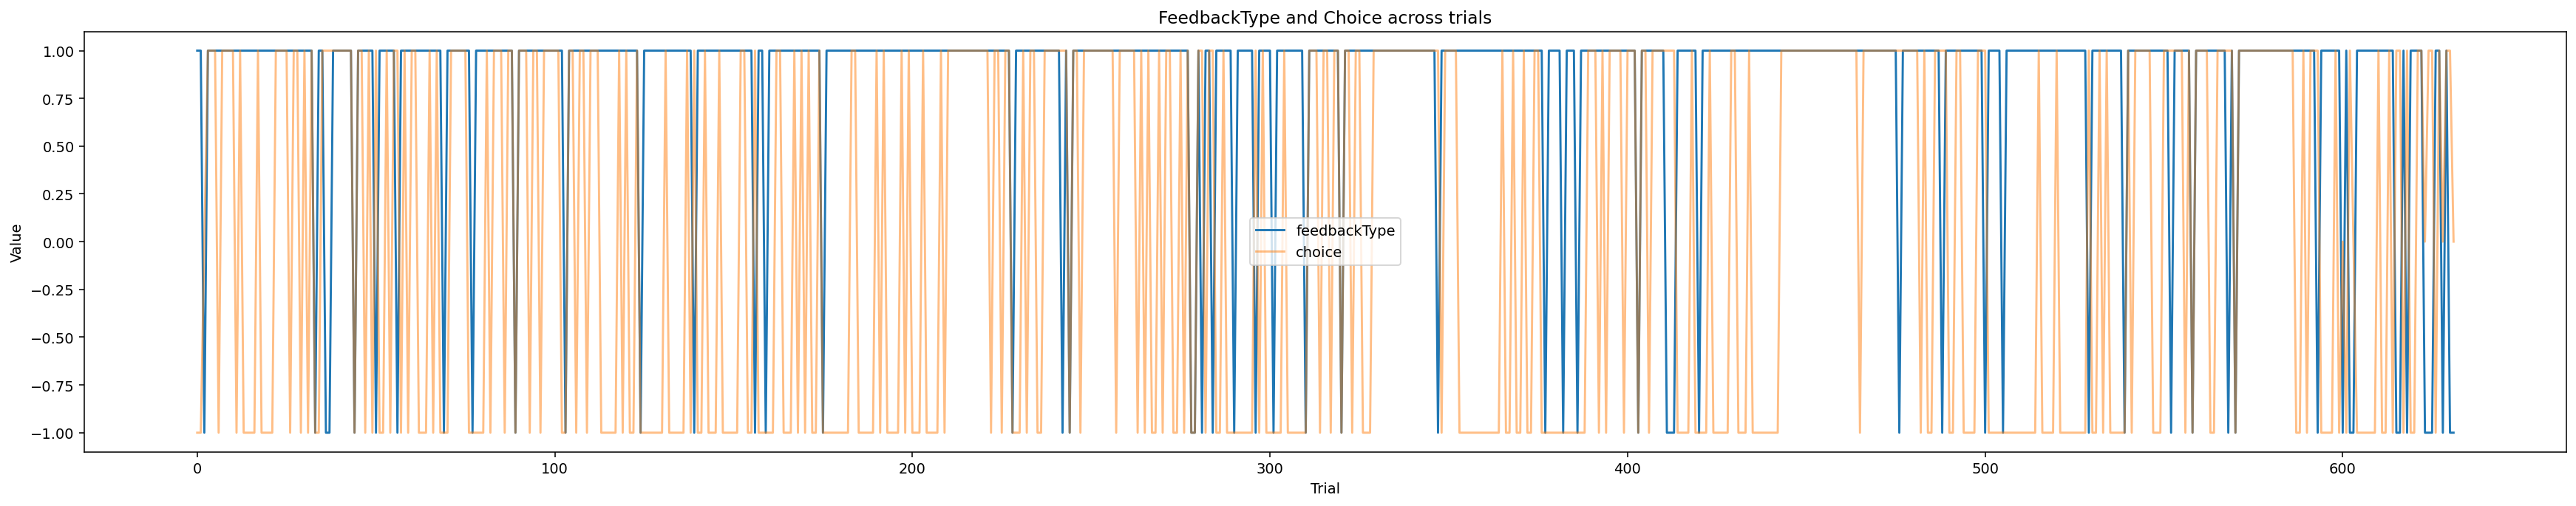

In [76]:

plt.figure(figsize=(25, 5))   # width=25, height=5 (in inches)
plt.plot(D['feedbackType'], label='feedbackType')
plt.plot(D['choice'], alpha=0.5, label='choice')
plt.legend()
plt.title('FeedbackType and Choice across trials')
plt.xlabel('Trial')
plt.ylabel('Value')
plt.tight_layout()
plt.show()

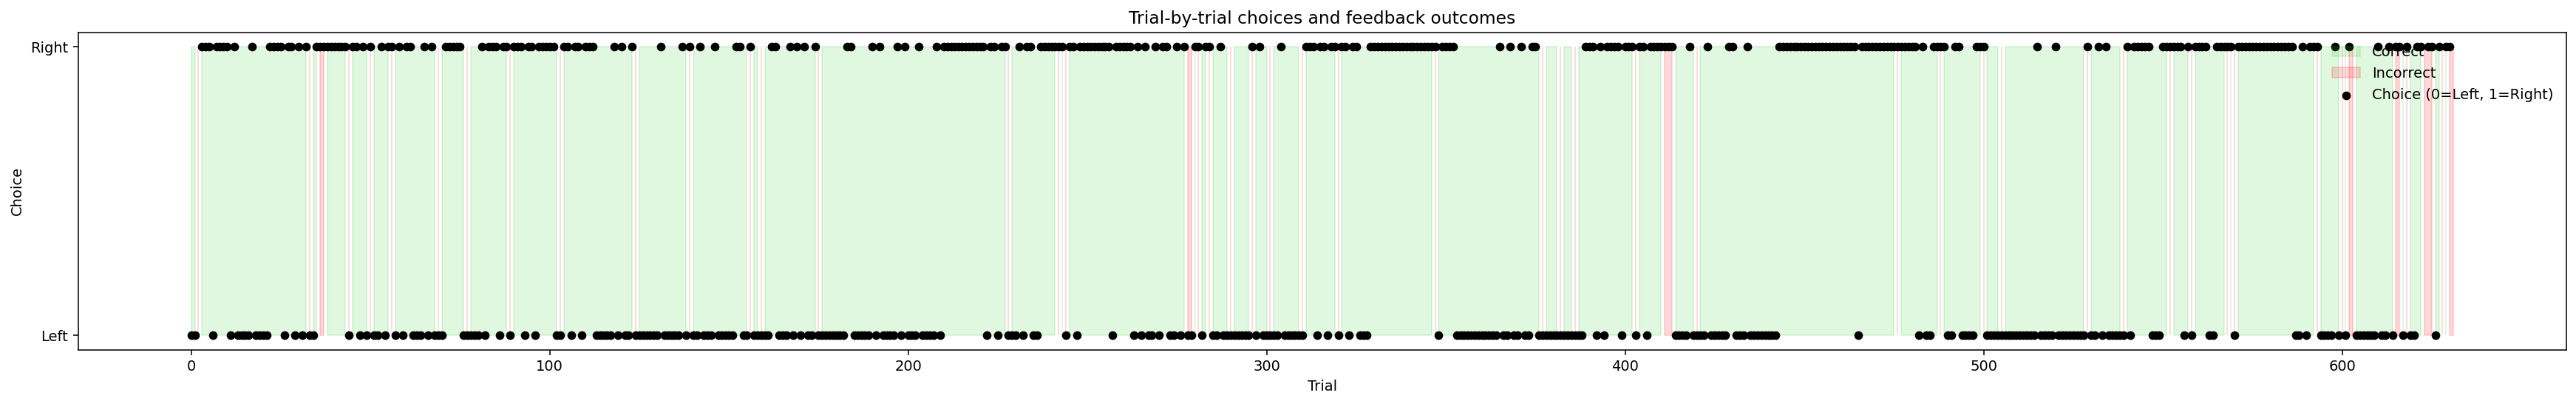

In [80]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(25, 4))

# 1. Define color masks
correct_mask = D['feedbackType'] == 1
incorrect_mask = D['feedbackType'] == -1

# 2. Shade regions for correct/incorrect trials
plt.fill_between(
    D.index, 0, 1, where=correct_mask, color='limegreen', alpha=0.15, label='Correct'
)
plt.fill_between(
    D.index, 0, 1, where=incorrect_mask, color='red', alpha=0.15, label='Incorrect'
)

# 3. Plot choices as dots (1 = right, 0 = left)
choice_right = D['choice'].replace({-1: 0, 1: 1, 0: np.nan})
plt.scatter(
    D.index, choice_right, c='k', s=25, label='Choice (0=Left, 1=Right)', zorder=3
)

# 4. Aesthetics
plt.yticks([0, 1], ['Left', 'Right'])
plt.xlabel('Trial')
plt.ylabel('Choice')
plt.title('Trial-by-trial choices and feedback outcomes')
plt.legend(loc='upper right', frameon=False)
plt.tight_layout()
plt.show()


✅ N trials: 633
Unique choice (mapped to choice_right): [1 0]
   allSContrasts  feedbackType  probabilityLeft
0          -1.00           1.0              0.5
1           0.00           1.0              0.5
2           0.00           1.0              0.5
3           0.00          -1.0              0.5
4          -0.25           1.0              0.5
Optimization terminated successfully.
         Current function value: 0.183799
         Iterations 11
                           Logit Regression Results                           
Dep. Variable:           choice_right   No. Observations:                  633
Model:                          Logit   Df Residuals:                      629
Method:                           MLE   Df Model:                            3
Date:                Thu, 09 Oct 2025   Pseudo R-squ.:                  0.7348
Time:                        17:29:36   Log-Likelihood:                -116.34
converged:                       True   LL-Null:                       -4

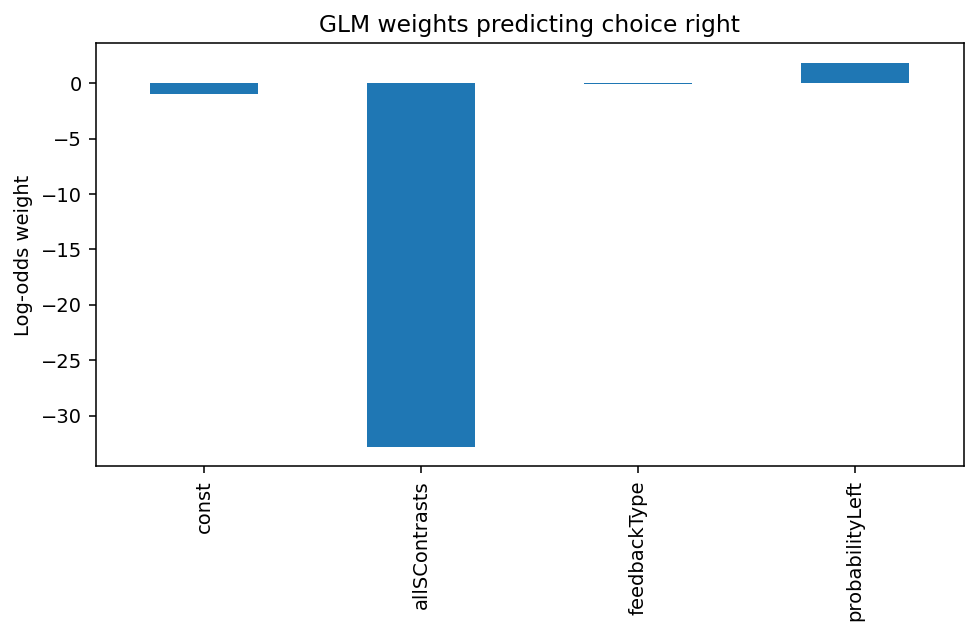

In [ ]:
"""
KB 09102025
Code to use GLM on 1 session to predict from 3 variables the outcome variable choice_right (1 = choice_right, 0 = choice_left) 

P(choice = right)=sigmoid(β0​+β1​allContrasts+β2​feedbackType+β3​probabilityLeft)
"""
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# =========================================================
# 1. Prepare data
# =========================================================
D = df_trials.copy().reset_index(drop=True)

# Outcome variable: 1 = correct, 0 = incorrect
D['choice_right'] = D['choice'].replace({-1: 0, 0: 0, 1: 1}).astype(int)

# Predictors
predictors = ['allContrasts', 'feedbackType', 'probabilityLeft']

# Ensures that all the predictor columns are numeric
for c in predictors:
    D[c] = pd.to_numeric(D[c], errors='coerce')

# Drop NaNs
D = D.dropna(subset=predictors + ['choice_right']).reset_index(drop=True)

print("✅ N trials:", len(D))
print("Unique choice (mapped to choice_right):", D['choice_right'].unique())
print(D[predictors].head())

# =========================================================
# 2. Fit logistic regression
# =========================================================
X = sm.add_constant(D[predictors])
y = D['choice_right']

model = sm.Logit(y, X)
result = model.fit()
print(result.summary())

# =========================================================
# 3. Visualize coefficients
# =========================================================
plt.figure(figsize=(8,4))
result.params.plot(kind='bar')
plt.ylabel('Log-odds weight')
plt.title('GLM weights predicting choice right')
plt.show()


✅ Trials: 633
Unique feedbackType: [1 0]
Optimization terminated successfully.
         Current function value: 0.183712
         Iterations 12
                           Logit Regression Results                           
Dep. Variable:                correct   No. Observations:                  633
Model:                          Logit   Df Residuals:                      627
Method:                           MLE   Df Model:                            5
Date:                Thu, 09 Oct 2025   Pseudo R-squ.:                  0.4139
Time:                        17:27:04   Log-Likelihood:                -116.29
converged:                       True   LL-Null:                       -198.43
Covariance Type:            nonrobust   LLR p-value:                 1.211e-33
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.0463      0.407      0.114  

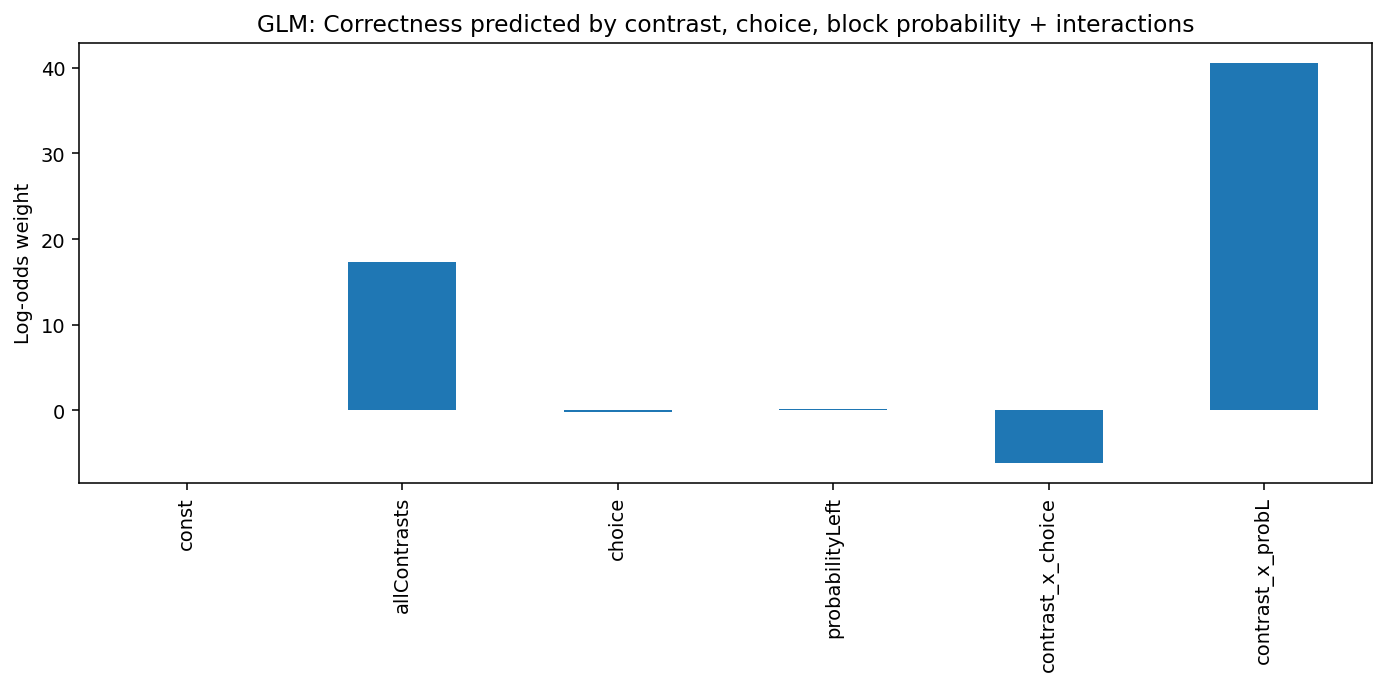

In [67]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# =========================================================
# 1. Prepare data
# =========================================================
D = df_trials.copy().reset_index(drop=True)

# Keep only valid choices
D = D[D['choice'].isin([-1, 0, 1])].copy()

# Binary outcome: 1 = correct, 0 = incorrect
D['correct'] = D['feedbackType'].replace({-1: 0, 1: 1}).astype(int)

# Base predictors
predictors = ['allContrasts', 'choice', 'probabilityLeft']

# Create interactions
D['contrast_x_choice'] = D['allContrasts'] * D['choice']
D['contrast_x_probL'] = D['allContrasts'] * D['probabilityLeft']

# Add them to predictors
predictors += ['contrast_x_choice', 'contrast_x_probL']

# Clean numerics
for c in predictors:
    D[c] = pd.to_numeric(D[c], errors='coerce')

D = D.dropna(subset=predictors + ['correct']).reset_index(drop=True)

print("✅ Trials:", len(D))
print("Unique feedbackType:", D['correct'].unique())

# =========================================================
# 2. Fit logistic regression
# =========================================================
X = sm.add_constant(D[predictors])
y = D['correct']

model = sm.Logit(y, X)
result = model.fit()
print(result.summary())

# =========================================================
# 3. Plot coefficients
# =========================================================
plt.figure(figsize=(10,5))
result.params.plot(kind='bar')
plt.title('GLM: Correctness predicted by contrast, choice, block probability + interactions')
plt.ylabel('Log-odds weight')
plt.tight_layout()
plt.show()


Trying HMMs 

state
0.0    576
1.0     51
NaN      5
Name: count, dtype: int64


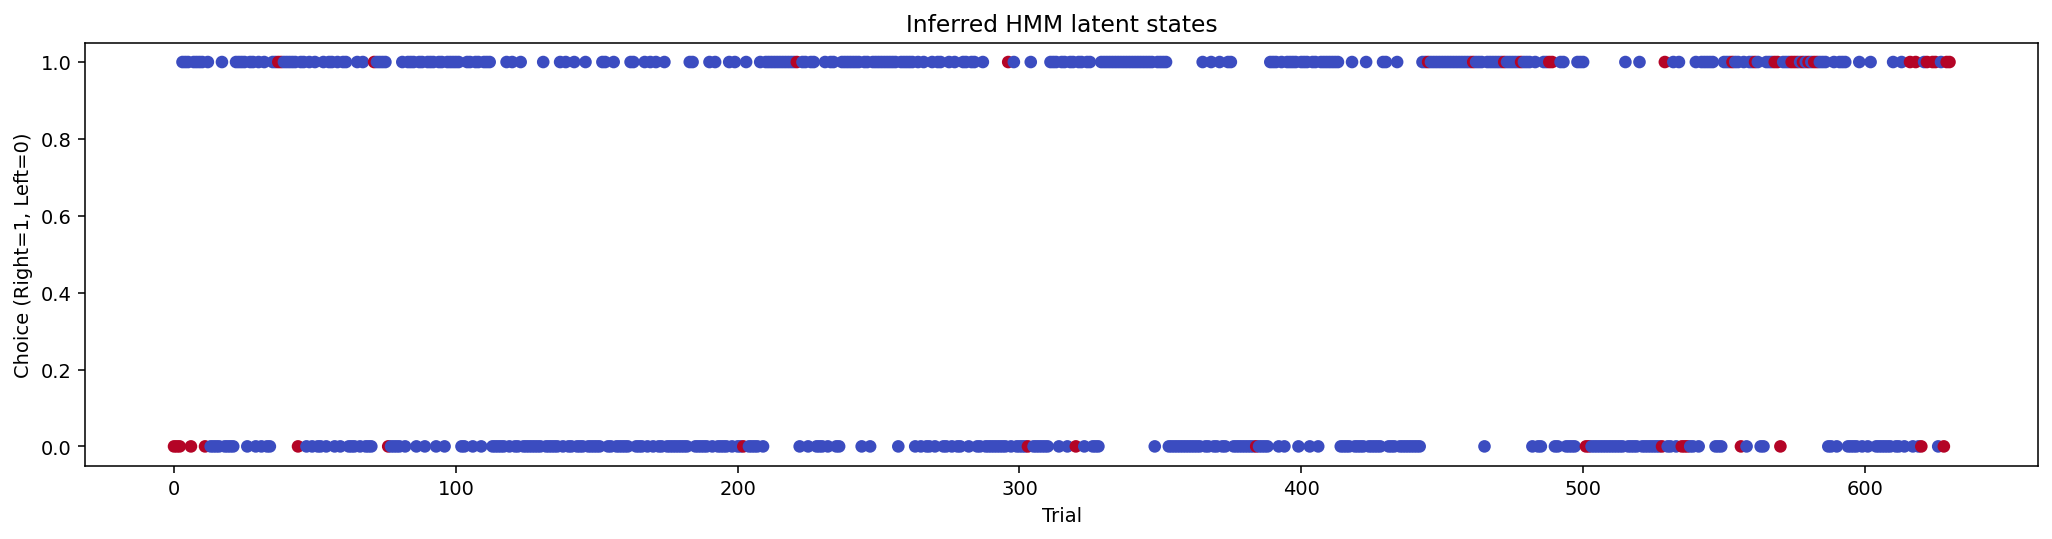

In [86]:
from hmmlearn import hmm
import numpy as np
import matplotlib.pyplot as plt

# Select observable variables
features = ['choice_right', 'reactionTime']
obs_df = D[features].dropna().copy()   # Keep track of trial indices
obs = obs_df.values                    # Numpy array for HMM

# Fit a 2-state Gaussian HMM
model = hmm.GaussianHMM(n_components=2, covariance_type='full', n_iter=200, random_state=0)
model.fit(obs)

# Infer hidden states
hidden_states = model.predict(obs)

# Assign states back using the same indices
D.loc[obs_df.index, 'state'] = hidden_states

# Check how many trials in each state
print(D['state'].value_counts(dropna=False))

# Plot
plt.figure(figsize=(18, 4))
plt.scatter(D.index, D['choice_right'], c=D['state'], cmap='coolwarm', s=30)
plt.title('Inferred HMM latent states')
plt.xlabel('Trial')
plt.ylabel('Choice (Right=1, Left=0)')
plt.show()



✅ state = 0 for ~576 trials (≈90%)

✅ state = 1 for ~51 trials

✅ NaN for 5 dropped rows

In [87]:
model.transmat_     # transition probabilities
model.means_        # mean observation per state
model.covars_       # variability per state


array([[[ 2.50011038e-01,  6.90937551e-03],
        [ 6.90937551e-03,  7.26860657e-03]],

       [[ 2.40474365e-01, -9.03474388e-01],
        [-9.03474388e-01,  1.34619680e+02]]])

In [88]:
summary = D.groupby('state')[['reactionTime', 'feedbackType', 'choice_right']].mean()
print(summary)


       reactionTime  feedbackType  choice_right
state                                          
0.0        0.243412      0.861111      0.503472
1.0        7.877978      0.411765      0.588235


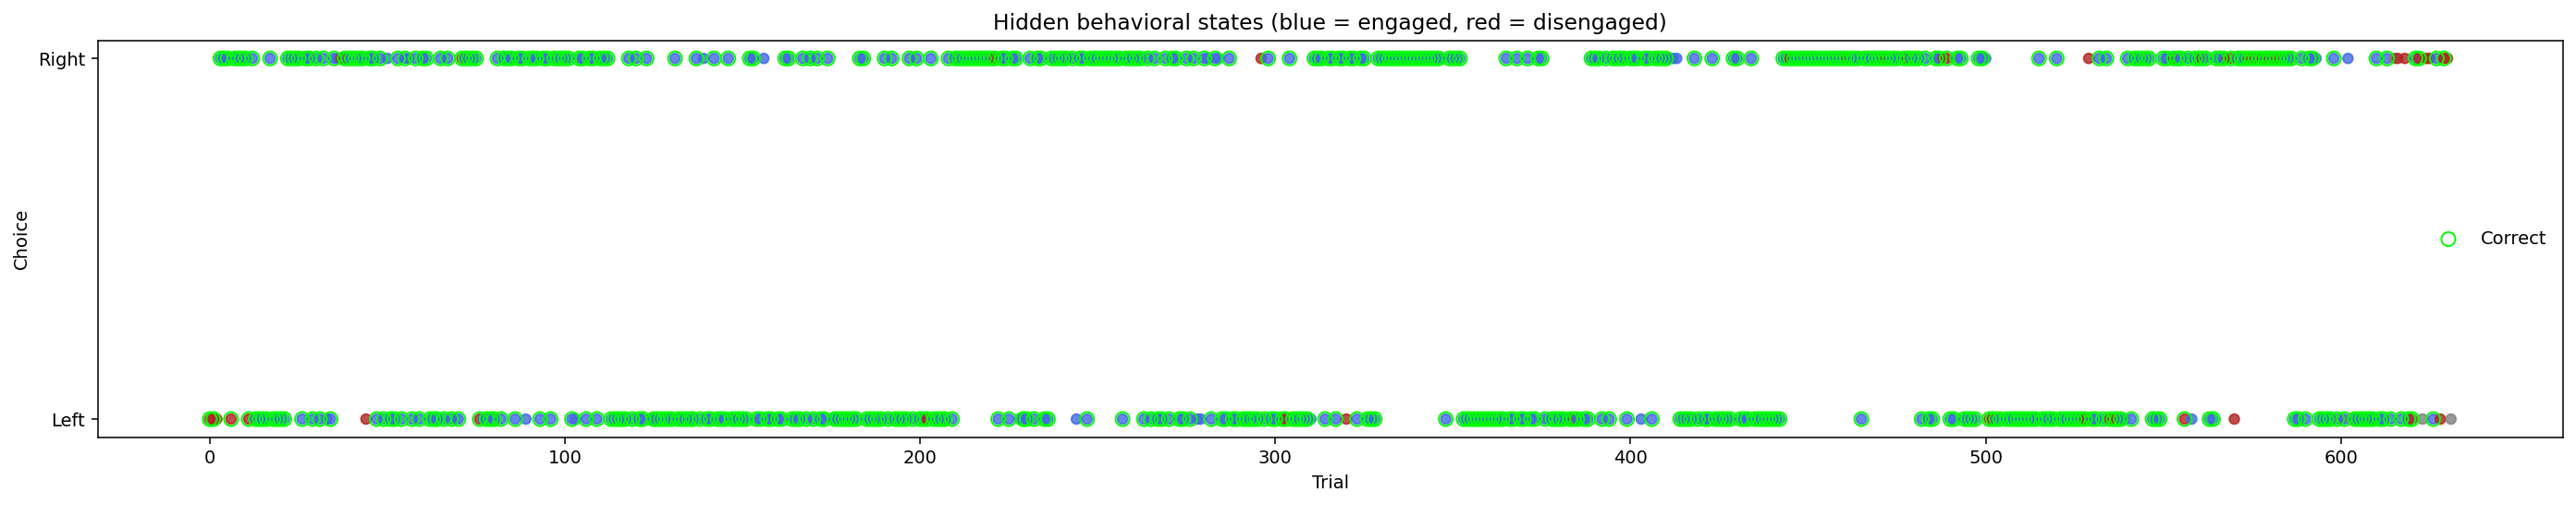

In [95]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 4))

# Define colors
state_colors = {0: 'royalblue', 1: 'firebrick'}

# Map to numeric states and use .map() + .to_list()
color_list = D['state'].map(state_colors).fillna('gray').to_list()

# Plot choices with state colors
plt.scatter(D.index, D['choice_right'], c=color_list, s=30, alpha=0.8)

# Highlight correct trials
correct_mask = D['feedbackType'] == 1
plt.scatter(D.index[correct_mask], D['choice_right'][correct_mask],
            facecolors='none', edgecolors='lime', s=60, label='Correct')

plt.yticks([0, 1], ['Left', 'Right'])
plt.xlabel('Trial')
plt.ylabel('Choice')
plt.title('Hidden behavioral states (blue = engaged, red = disengaged)')
plt.legend(frameon=False)
plt.tight_layout()
plt.show()



In [90]:
# Compute mean feedback per state
state_perf = D.groupby('state')['feedbackType'].mean()

# The state with higher accuracy = 'engaged'
engaged_state = state_perf.idxmax()
D['state_label'] = np.where(D['state'] == engaged_state, 'engaged', 'disengaged')

print(D['state_label'].value_counts())


state_label
engaged       576
disengaged     56
Name: count, dtype: int64


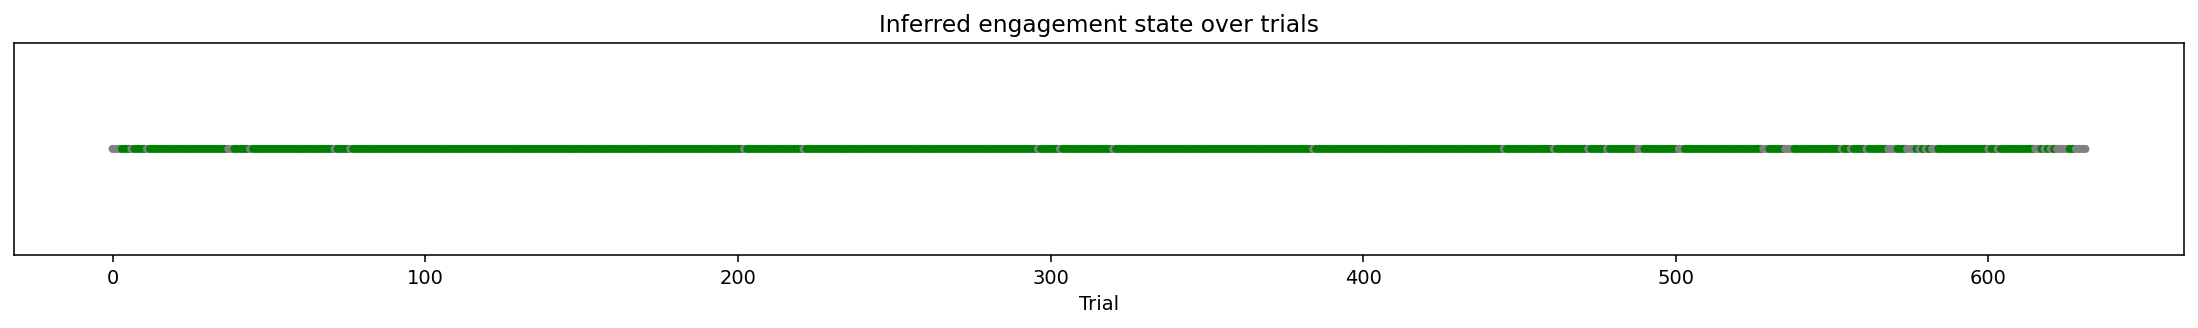

In [91]:
plt.figure(figsize=(20, 2))
plt.scatter(D.index, [1]*len(D), c=D['state_label'].map({'engaged':'green','disengaged':'gray'}), s=10)
plt.title('Inferred engagement state over trials')
plt.yticks([])
plt.xlabel('Trial')
plt.show()


Trying HMM part 2 - exploring

In [99]:
""" 1. IMPORTS """ 
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
from functions import *
import sys
sys.path.insert(0, "/home/kceniabougrova/Documents/GitHub/ibl-photometry/src")


df_good_BCW = pd.read_excel("/home/kceniabougrova/Downloads/good_sessions_outputs/df_good_BCW.xlsx")

i = 56
row = df_good_BCW.iloc[i]

# =========================================================
# Extract metadata
# =========================================================
subject = row['subject']
date = str(row['date'])[:10]
region = row['region']
fiber = row['fiber']
eid = row['eid']

print(f"📦 Session {i} — {subject} | {date} | {region} | {fiber} | {eid}")

# =========================================================
# Locate corresponding files in your folder
# =========================================================
BASE_DIR = "/home/kceniabougrova/Downloads/good_sessions_outputs/"

df_trials_file = [
    f for f in os.listdir(BASE_DIR)
    if f.startswith("df_trials_")
    and subject in f
    and date in f
    and region in f
    and eid in f
]

df_nph_file = [
    f for f in os.listdir(BASE_DIR)
    if f.startswith("df_nph_")
    and subject in f
    and date in f
    and region in f
    and eid in f
]

if not df_trials_file or not df_nph_file:
    print("⚠️ Missing one or both files in folder!")
else:
    df_trials_path = os.path.join(BASE_DIR, df_trials_file[0])
    df_nph_path = os.path.join(BASE_DIR, df_nph_file[0])

    print(f"✅ Found df_trials -> {df_trials_path}")
    print(f"✅ Found df_nph -> {df_nph_path}")

    # Load them
    df_trials = pd.read_csv(df_trials_path)
    df_nph = pd.read_csv(df_nph_path)

    print(f"df_trials shape: {df_trials.shape}")
    print(f"df_nph shape: {df_nph.shape}")



# =========================================================
# HMM test
# =========================================================
from hmmlearn import hmm
import numpy as np
import matplotlib.pyplot as plt

# Select observable variables
features = ['feedbackType', 'reactionTime', 'quiescenceTime', 'probabilityLeft', 'allContrasts']
obs_df = D[features].dropna().copy()   # Keep track of trial indices
obs = obs_df.values                    # Numpy array for HMM

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
obs_scaled = scaler.fit_transform(obs)

from math import log
N = len(obs_scaled)
for k in [2, 3, 4]:
    model = hmm.GaussianHMM(n_components=k, covariance_type='full', n_iter=200, random_state=0)
    model.fit(obs_scaled)
    ll = model.score(obs_scaled)
    n_params = k**2 + 2*k*obs_scaled.shape[1] - 1  # rough estimate
    bic = -2*ll + n_params*log(N)
    print(f"k={k}: logL={ll:.1f}, BIC={bic:.1f}")


D.loc[obs_df.index, 'state'] = hidden_states
print(D['state'].value_counts(dropna=False))

summary = D.groupby('state')[features + ['choice_right']].mean()
print(summary)



📦 Session 56 — ZFM-04019 | 2022-06-08 | Region5G | probe11 | 29edc532-0498-4b59-9476-c2f032309778
✅ Found df_trials -> /home/kceniabougrova/Downloads/good_sessions_outputs/df_trials_174_ZFM-04019_2022-06-08_Region5G_29edc532-0498-4b59-9476-c2f032309778.csv
✅ Found df_nph -> /home/kceniabougrova/Downloads/good_sessions_outputs/df_nph_174_ZFM-04019_2022-06-08_Region5G_29edc532-0498-4b59-9476-c2f032309778.csv
df_trials shape: (773, 29)
df_nph shape: (149906, 4)
k=2: logL=670.4, BIC=-1192.8


Model is not converging.  Current: 2925.9370859993214 is not greater than 2925.9949478381614. Delta is -0.05786183883992635
Model is not converging.  Current: 4344.532256247517 is not greater than 4428.232704288688. Delta is -83.70044804117151


k=3: logL=2926.3, BIC=-5607.8
k=4: logL=4628.5, BIC=-8902.8
state
0.0    576
1.0     51
NaN      5
Name: count, dtype: int64
       feedbackType  reactionTime  quiescenceTime  probabilityLeft  \
state                                                                
0.0        0.861111      0.243412        0.837953         0.495313   
1.0        0.411765      7.877978        1.055924         0.505882   

       allContrasts  choice_right  
state                              
0.0        0.315864      0.503472  
1.0        0.083333      0.588235  


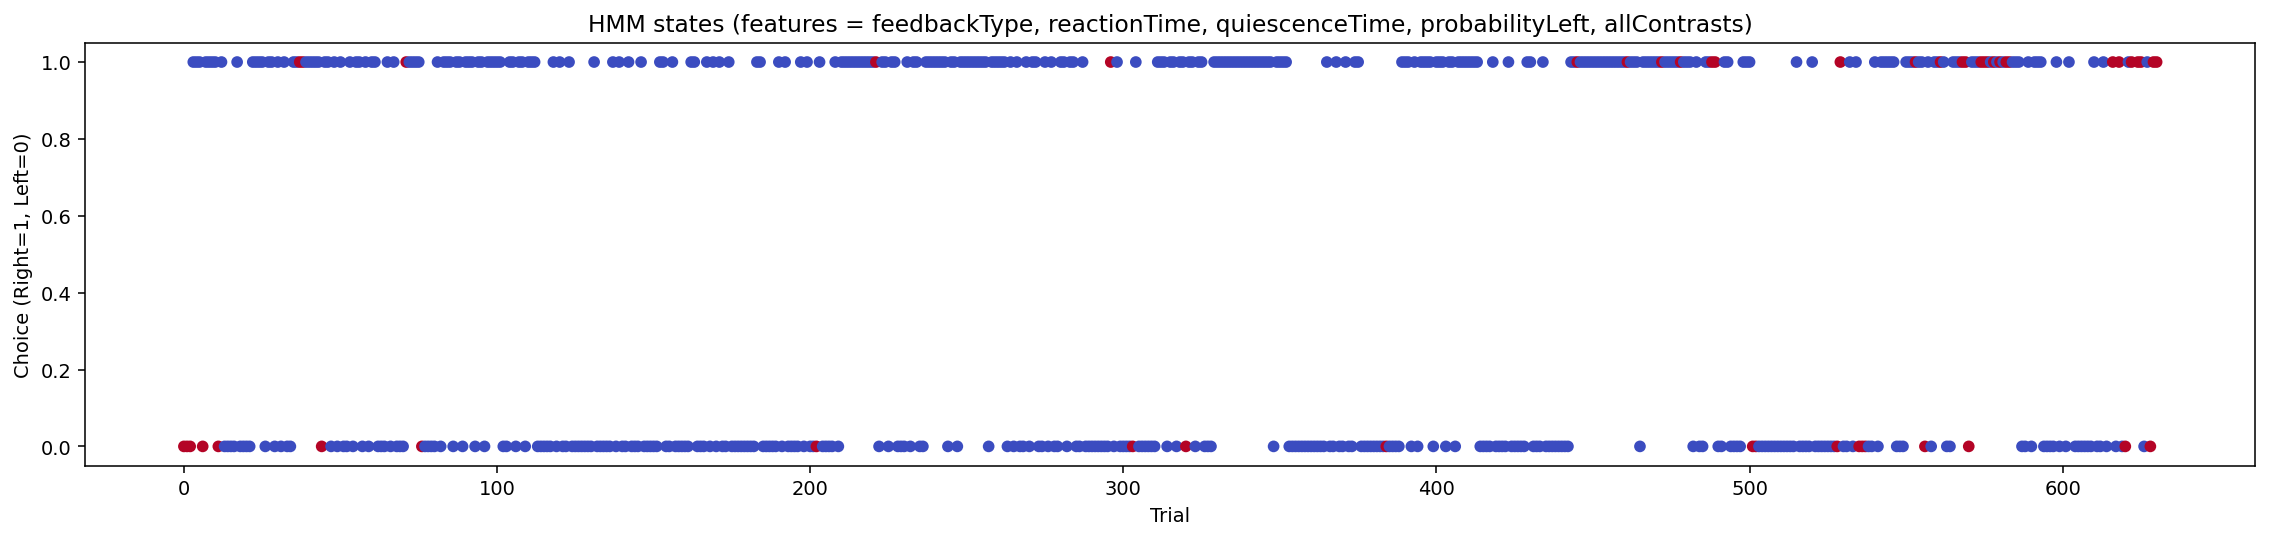

In [100]:
plt.figure(figsize=(20, 4))
plt.scatter(D.index, D['choice_right'], c=D['state'], cmap='coolwarm', s=25)
plt.title(f"HMM states (features = {', '.join(features)})")
plt.xlabel('Trial')
plt.ylabel('Choice (Right=1, Left=0)')
plt.show()


In [101]:
model = hmm.GaussianHMM(n_components=4, covariance_type='full', n_iter=500, tol=1e-4, random_state=42)
model.fit(obs_scaled)


,n_components,4
,covariance_type,'full'
,min_covar,0.001
,startprob_prior,1.0
,transmat_prior,1.0
,means_prior,0
,means_weight,0
,covars_prior,0.01
,covars_weight,1
,algorithm,'viterbi'
,random_state,42


In [102]:
best_model, best_ll = None, -np.inf
for seed in range(5):
    model = hmm.GaussianHMM(n_components=4, covariance_type='full', n_iter=500, random_state=seed)
    model.fit(obs_scaled)
    ll = model.score(obs_scaled)
    if ll > best_ll:
        best_ll, best_model = ll, model
print("Best logL:", best_ll)
hidden_states = best_model.predict(obs_scaled)


Model is not converging.  Current: 4344.532256247517 is not greater than 4428.232704288688. Delta is -83.70044804117151
Model is not converging.  Current: 3001.6037706964607 is not greater than 3001.6577090314795. Delta is -0.053938335018756334
Model is not converging.  Current: 2500.992415614989 is not greater than 3601.8651050972426. Delta is -1100.8726894822535


Best logL: 4628.51235578215


In [103]:
summary = D.groupby('state')[['reactionTime','feedbackType']].mean()
engaged_state = summary['feedbackType'].idxmax()
D['state_label'] = np.where(D['state'] == engaged_state, 'engaged', 'disengaged')


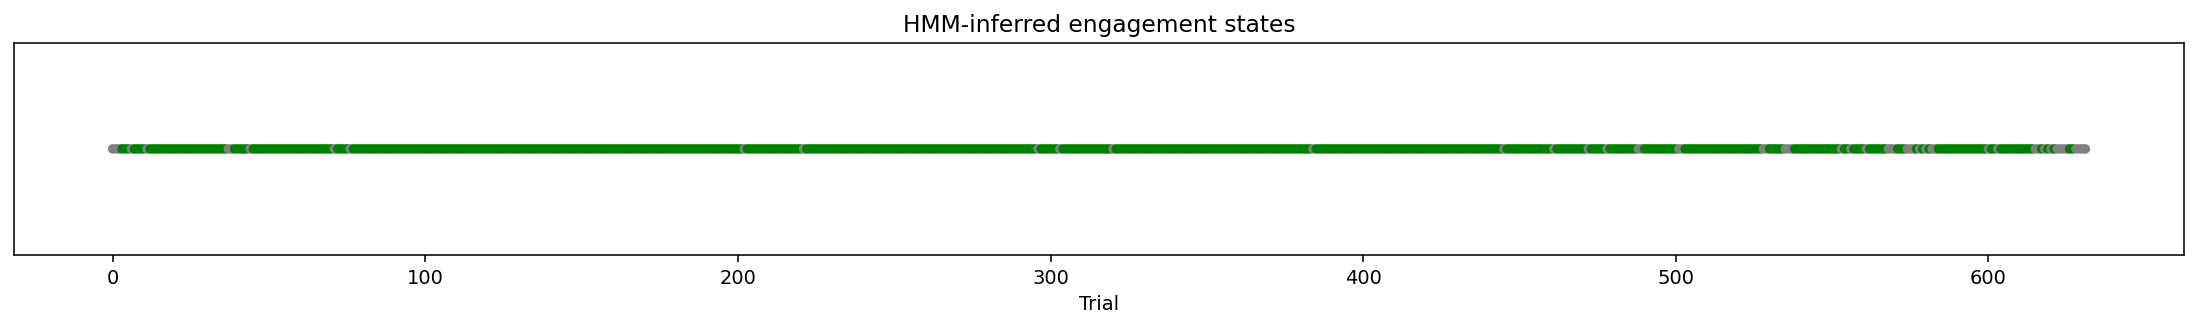

In [104]:
plt.figure(figsize=(20,2))
plt.scatter(D.index, [1]*len(D), 
            c=D['state_label'].map({'engaged':'green','disengaged':'gray'}), s=15)
plt.title('HMM-inferred engagement states')
plt.yticks([]); plt.xlabel('Trial'); plt.show()


In [107]:
# Merge on trial or time if aligned
# Example: average z-dFF per state
df_summary = df_nph.merge(D[['state_label']], left_on='times', right_index=True, how='left')
state_means = df_summary.groupby('state_label')['zdFF'].mean()
print(state_means)


Series([], Name: zdFF, dtype: float64)


<ipython-input-107-81991efe1276>:3: UserWarning: You are merging on int and float columns where the float values are not equal to their int representation.
  df_summary = df_nph.merge(D[['state_label']], left_on='times', right_index=True, how='left')


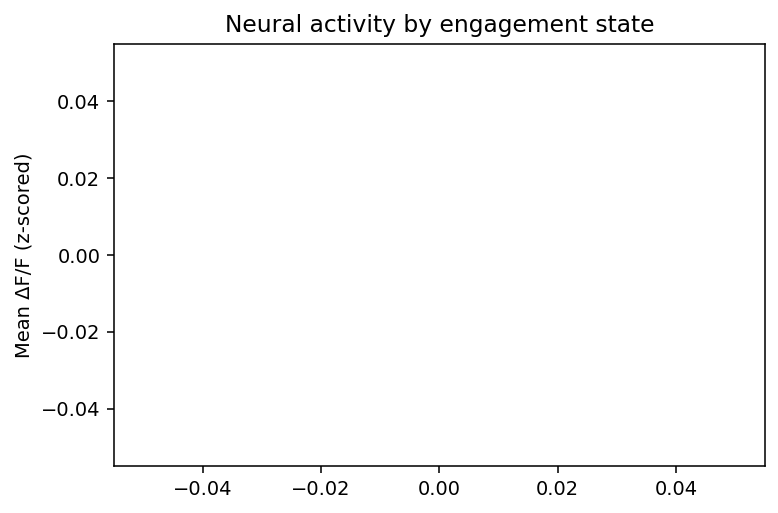

In [108]:
plt.bar(state_means.index, state_means.values, color=['gray','green'])
plt.ylabel('Mean ΔF/F (z-scored)')
plt.title('Neural activity by engagement state')
plt.show()


In [109]:
model = hmm.GaussianHMM(
    n_components=4, covariance_type='full',
    n_iter=1000, tol=1e-3, random_state=seed, verbose=True
)


In [110]:
summary = D.groupby('state')[['feedbackType','reactionTime','allContrasts','quiescenceTime']].mean().sort_values('reactionTime')
print(summary)


       feedbackType  reactionTime  allContrasts  quiescenceTime
state                                                          
0.0        0.861111      0.243412      0.315864        0.837953
1.0        0.411765      7.877978      0.083333        1.055924


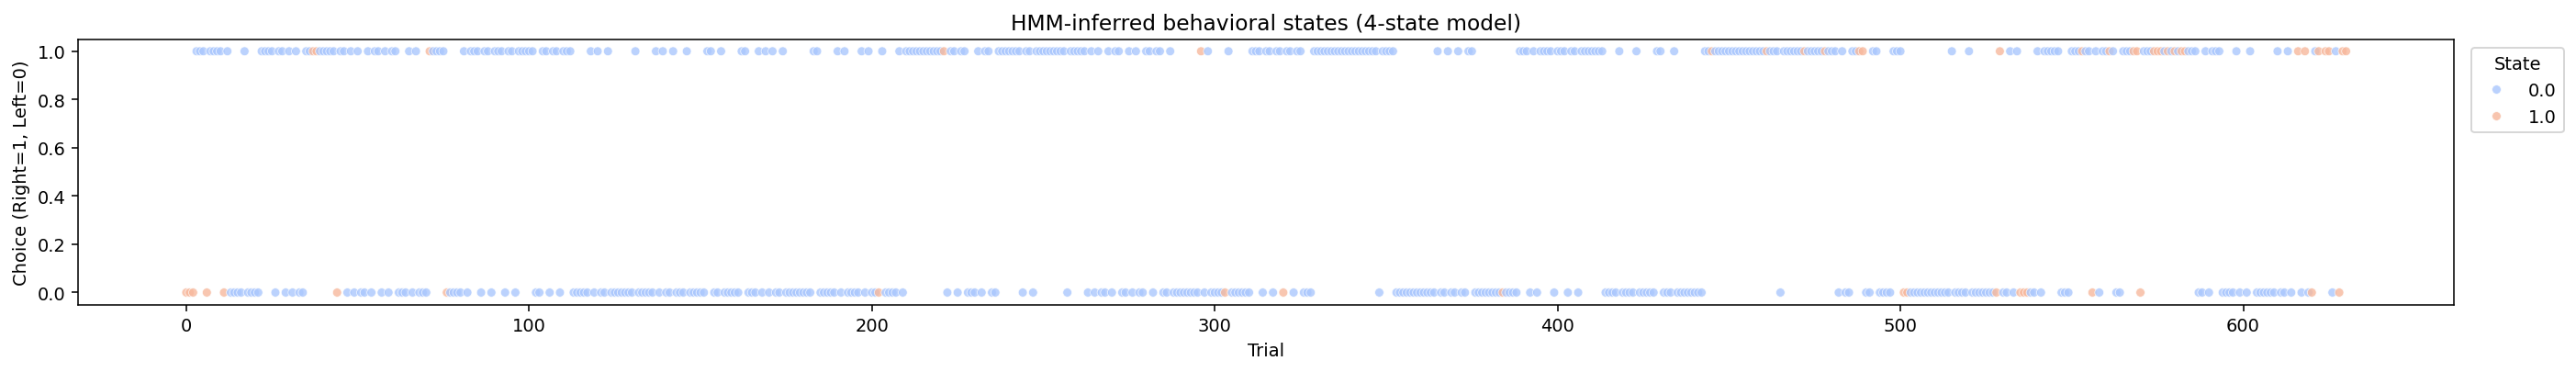

In [111]:
import seaborn as sns
plt.figure(figsize=(20, 3))
sns.scatterplot(x=D.index, y=D['choice_right'], hue=D['state'], 
                palette='coolwarm', s=25, alpha=0.8)
plt.title('HMM-inferred behavioral states (4-state model)')
plt.xlabel('Trial'); plt.ylabel('Choice (Right=1, Left=0)')
plt.legend(title='State', bbox_to_anchor=(1.05, 1))
plt.tight_layout(); plt.show()


In [112]:
summary = D.groupby('state')[['feedbackType','reactionTime']].mean()
# Higher accuracy = more engaged
sorted_states = summary.sort_values('feedbackType', ascending=False).index
state_labels = {sorted_states[0]:'highly_engaged',
                sorted_states[1]:'engaged',
                sorted_states[2]:'distracted',
                sorted_states[3]:'disengaged'}
D['state_label'] = D['state'].map(state_labels)
print(D['state_label'].value_counts())


IndexError: index 2 is out of bounds for axis 0 with size 2

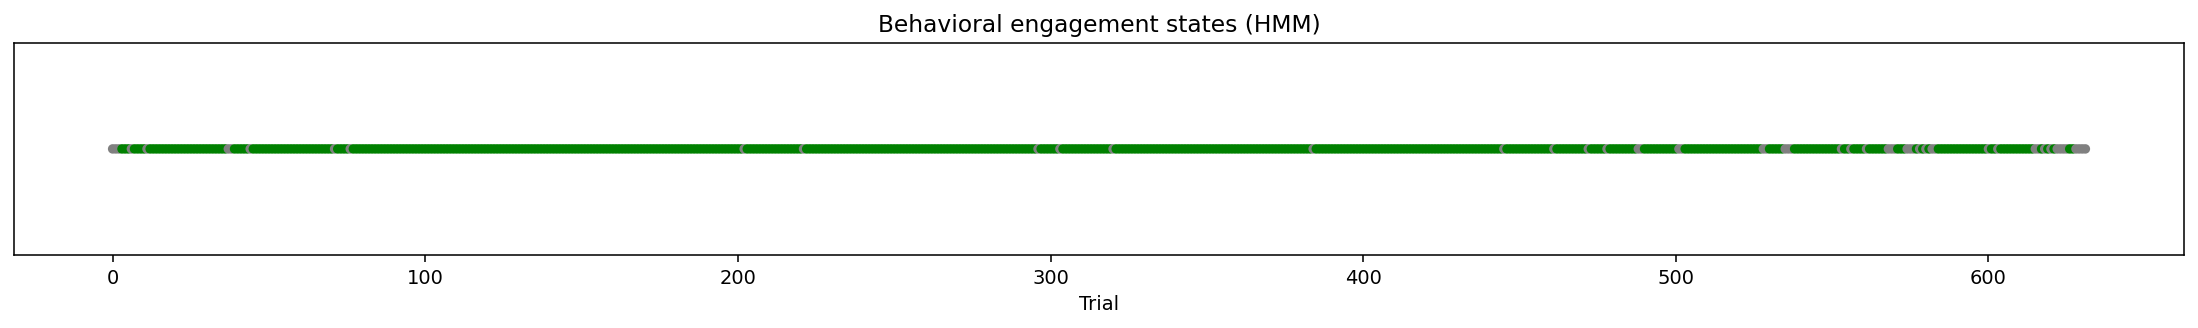

In [113]:
plt.figure(figsize=(20,2))
plt.scatter(D.index, [1]*len(D),
            c=D['state_label'].map({
                'highly_engaged':'limegreen',
                'engaged':'green',
                'distracted':'orange',
                'disengaged':'gray'
            }), s=15)
plt.yticks([]); plt.xlabel('Trial')
plt.title('Behavioral engagement states (HMM)')
plt.show()


In [114]:
from math import log
from hmmlearn import hmm
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
obs_scaled = scaler.fit_transform(obs)

results = []
for k in range(2, 6):
    model = hmm.GaussianHMM(n_components=k, covariance_type='full',
                            n_iter=500, random_state=0)
    model.fit(obs_scaled)
    ll = model.score(obs_scaled)
    n_params = k**2 + 2*k*obs_scaled.shape[1] - 1
    bic = -2*ll + n_params*log(len(obs_scaled))
    results.append((k, ll, bic))

for k, ll, bic in results:
    print(f"k={k}: logL={ll:.1f}, BIC={bic:.1f}")


Model is not converging.  Current: 2925.9370859993214 is not greater than 2925.9949478381614. Delta is -0.05786183883992635
Model is not converging.  Current: 4344.532256247517 is not greater than 4428.232704288688. Delta is -83.70044804117151


k=2: logL=670.4, BIC=-1192.8
k=3: logL=2926.3, BIC=-5607.8
k=4: logL=4628.5, BIC=-8902.8
k=5: logL=1586.6, BIC=-2696.6


In [115]:
model = hmm.GaussianHMM(n_components=4, covariance_type='full',
                        n_iter=1000, tol=1e-3, random_state=0)


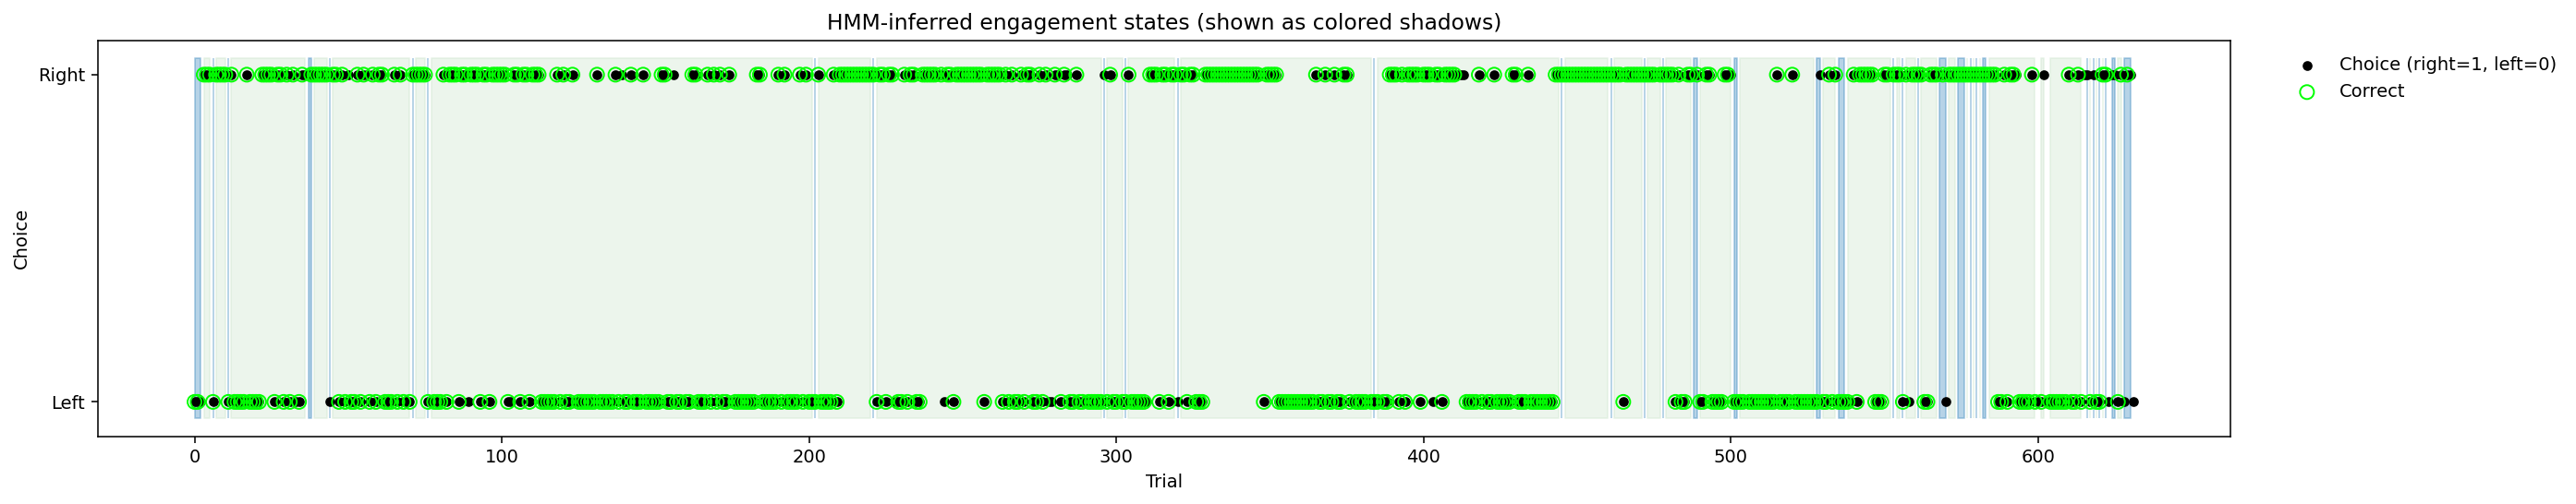

In [119]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches

plt.figure(figsize=(20, 4))

# Your behavioural trace — e.g., right choices as dots
plt.scatter(D.index, D['choice_right'], c='k', s=20, label='Choice (right=1, left=0)', zorder=3)

# -------------------------------------------------------------------
#  SHADOWS for HMM states
# -------------------------------------------------------------------
colors = ["#D0E8D1", "#4A93C3", '#FFC107', '#FF5722']  # 4 distinct colors (greens→reds)
for s in sorted(D['state'].dropna().unique()):
    mask = D['state'] == s
    plt.fill_between(
        D.index, -0.05, 1.05,
        where=mask,
        color=colors[int(s) % len(colors)],
        alpha=0.4,
        step='mid'
    )

# Optional: correct trials overlay (green ring)
correct_mask = D['feedbackType'] == 1
plt.scatter(D.index[correct_mask], D['choice_right'][correct_mask],
            facecolors='none', edgecolors='lime', s=60, label='Correct', zorder=4)

# -------------------------------------------------------------------
#  STYLE
# -------------------------------------------------------------------
plt.yticks([0, 1], ['Left', 'Right'])
plt.xlabel('Trial')
plt.ylabel('Choice')
plt.title('HMM-inferred engagement states (shown as colored shadows)')
plt.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [124]:
model.fit(obs)



,n_components,4
,covariance_type,'full'
,min_covar,0.001
,startprob_prior,1.0
,transmat_prior,1.0
,means_prior,0
,means_weight,0
,covars_prior,0.01
,covars_weight,1
,algorithm,'viterbi'
,random_state,0


In [125]:
state_means = pd.DataFrame(model.means_, columns=features)
print(state_means.round(3))


   feedbackType  reactionTime  quiescenceTime  probabilityLeft  allContrasts
0         1.000         0.243           0.833            0.495         0.338
1        -0.500        42.874           1.217            0.275         0.078
2         1.000        23.870           0.551            0.650         0.000
3        -0.341         2.459           1.005            0.511         0.029


<Figure size 1400x700 with 0 Axes>

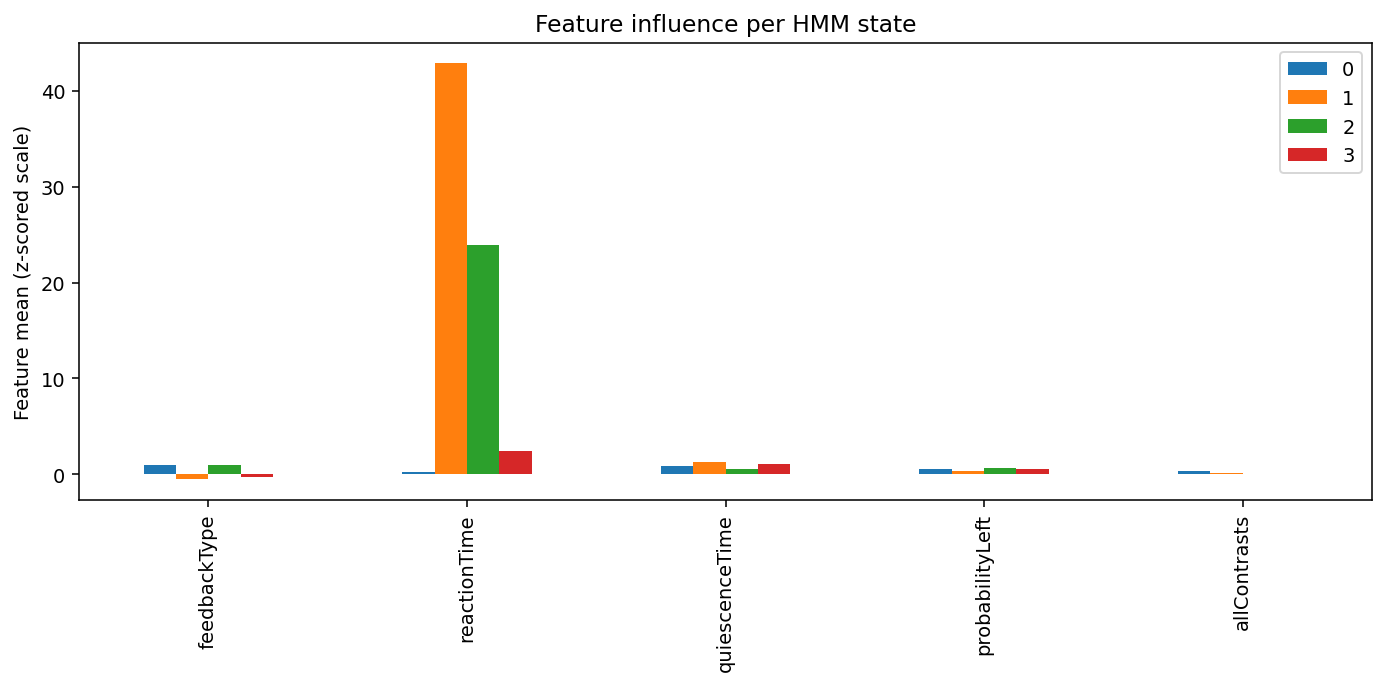

In [127]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
state_means.T.plot(kind='bar', figsize=(10,5))
plt.ylabel('Feature mean (z-scored scale)')
plt.title('Feature influence per HMM state')
plt.tight_layout()
plt.show()



In [128]:
influence = state_means.std(axis=0).sort_values(ascending=False)
print("Feature influence ranking:\n", influence)


Feature influence ranking:
 reactionTime       20.069869
feedbackType        0.822745
quiescenceTime      0.281307
probabilityLeft     0.154988
allContrasts        0.154585
dtype: float64


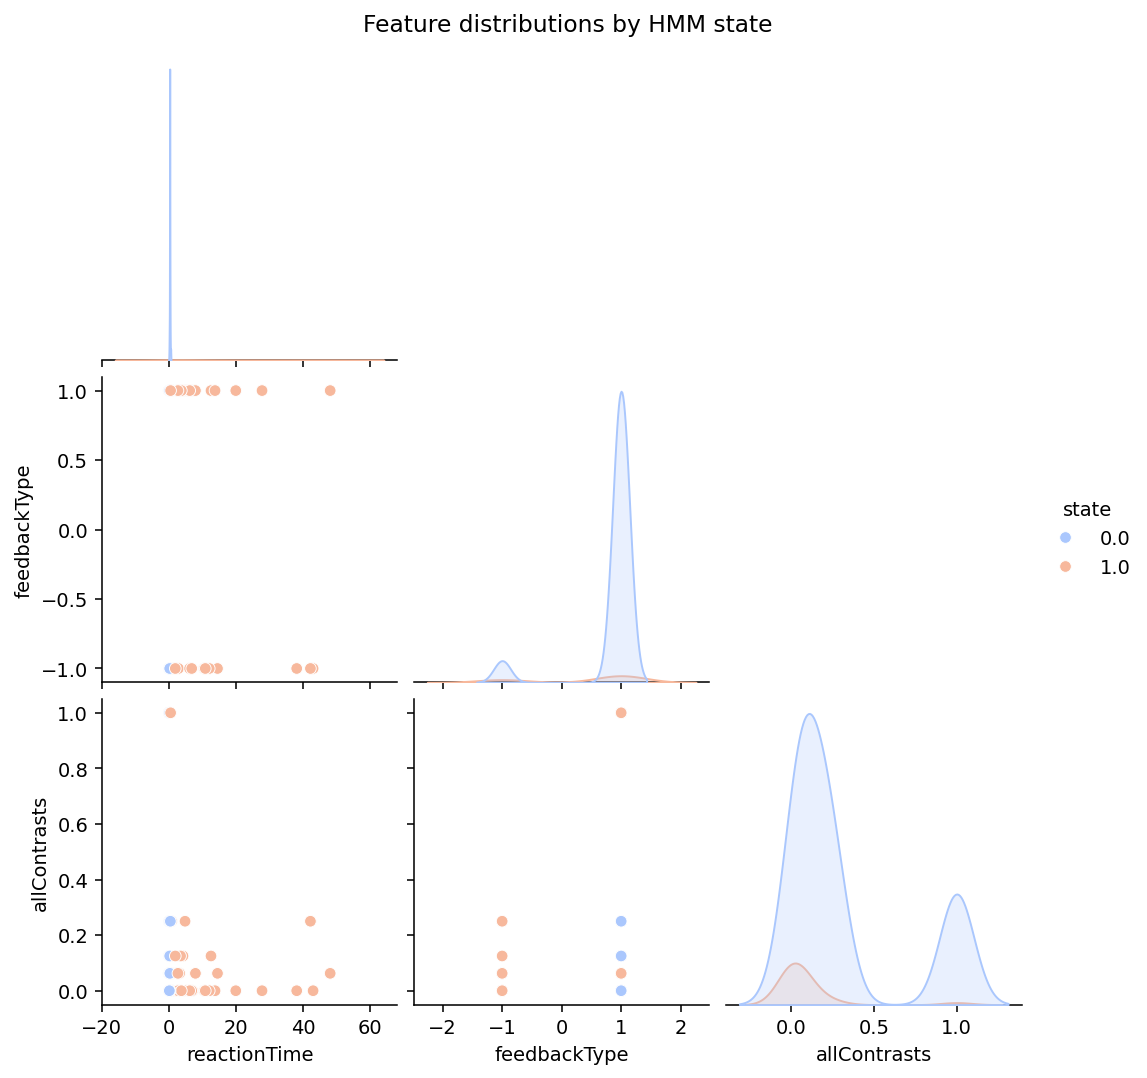

In [130]:
import seaborn as sns

sns.pairplot(obs_df.assign(state=D['state']),
             vars=['reactionTime','feedbackType','allContrasts'],
             hue='state', palette='coolwarm', corner=True)
plt.suptitle('Feature distributions by HMM state', y=1.02)
plt.show()

